TASK 1

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Print dataset information
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

# Class names
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8243 - loss: 0.4917 - val_accuracy: 0.8399 - val_loss: 0.4263
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8662 - loss: 0.3674 - val_accuracy: 0.8595 - val_loss: 0.3892
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8774 - loss: 0.3328 - val_accuracy: 0.8700 - val_loss: 0.3668
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8855 - loss: 0.3097 - val_accuracy: 0.8716 - val_loss: 0.3583
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8928 - loss: 0.2913 - val_accuracy: 0.8764 - val_loss: 0.3483
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8956 - loss: 0.2788 - val_accuracy: 0.8755 - val_loss: 0.3408
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9010 - loss: 0.2657 - val_accuracy: 0.8797 - val_loss: 0.3419
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9020 - loss: 0.2582 - 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

# Convert one-hot labels back to integers
y_true = np.argmax(y_test, axis=1)

# Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision :", precision_score(y_true, y_pred, average='weighted'))
print("Recall :", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8857
Precision : 0.8865690216925319
Recall : 0.8857
F1 Score : 0.8848632195585675

Confusion Matrix
[[854   1  16  20   3   3  98   0   5   0]
 [  4 973   2  15   3   0   2   0   1   0]
 [ 14   0 867  13  64   0  40   0   2   0]
 [ 21   5  13 901  37   0  17   0   6   0]
 [  0   0 172  29 769   0  28   0   2   0]
 [  0   0   0   1   0 976   0  14   0   9]
 [126   1 103  27 105   0 633   0   5   0]
 [  0   0   0   0   0  16   0 968   0  16]
 [  3   1   4   6   7   5   3   3 968   0]
 [  1   0   0   0   0  14   0  37   0 948]]

Classification Report
              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.74      0.87      0.80      1000
       Dress       0.89      0.90      0.90      1000
        Coat       0.78      0.77      0.77      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt 

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
pip install scikeras

In [ ]:
# ==========================================================
# TASK 1 : BUILD A BASELINE MLP MODEL
# ==========================================================

import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

from scikeras.wrappers import KerasClassifier

# ---------------------------------------------------------
# Load Fashion MNIST Dataset
# ---------------------------------------------------------

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# ---------------------------------------------------------
# Build Baseline Model
# ---------------------------------------------------------

baseline_model = Sequential([

    Input(shape=(784,)),

    Dense(128,activation='relu'),

    Dense(64,activation='relu'),

    Dense(10,activation='softmax')

])

baseline_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

print("Training Baseline Model...\n")

baseline_history = baseline_model.fit(

    x_train,
    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2,

    verbose=1

)

baseline_loss,baseline_accuracy=baseline_model.evaluate(

    x_test,
    y_test,
    verbose=0

)

print("\nBaseline Accuracy :",baseline_accuracy)

Training Baseline Model...

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8189 - loss: 0.5076 - val_accuracy: 0.8506 - val_loss: 0.4119
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8624 - loss: 0.3791 - val_accuracy: 0.8617 - val_loss: 0.3771
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8750 - loss: 0.3385 - val_accuracy: 0.8645 - val_loss: 0.3758
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8828 - loss: 0.3169 - val_accuracy: 0.8583 - val_loss: 0.3759
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8891 - loss: 0.2997 - val_accuracy: 0.8719 - val_loss: 0.3596
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8940 - loss: 0.2841 - val_accuracy: 0.8780 - val_loss: 0.3367
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8994 - loss: 0.2680 - val_accuracy: 0.8826 - val_loss: 0.3317
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - acc

In [ ]:
# ==========================================================
# TASK 2 : DEFINE HYPERPARAMETER SEARCH SPACE
# ==========================================================

def create_model(

    hidden_layers=1,

    hidden_neurons=128,

    learning_rate=0.001,

    optimizer="Adam",

    activation="relu",

    dropout_rate=0.0

):

    model=Sequential()

    model.add(Input(shape=(784,)))

    for i in range(hidden_layers):

        model.add(Dense(

            hidden_neurons,

            activation=activation

        ))

        if dropout_rate>0:

            model.add(Dropout(dropout_rate))

    model.add(Dense(10,activation='softmax'))

    if optimizer=="SGD":

        opt=SGD(learning_rate=learning_rate)

    elif optimizer=="Adam":

        opt=Adam(learning_rate=learning_rate)

    else:

        opt=RMSprop(learning_rate=learning_rate)

    model.compile(

        optimizer=opt,

        loss='sparse_categorical_crossentropy',

        metrics=['accuracy']

    )

    return model


model=KerasClassifier(

    model=create_model,

    verbose=0

)


param_grid={

    "model__hidden_layers":[1,2,3],

    "model__hidden_neurons":[32,64,128,256],

    "model__learning_rate":[0.1,0.01,0.001],

    "batch_size":[16,32,64,128],

    "epochs":[10,20,30],

    "model__optimizer":["SGD","Adam","RMSprop"],

    "model__activation":["relu","tanh","sigmoid"],

    "model__dropout_rate":[0.0,0.2,0.5]

}

In [ ]:
# ==========================================================
# TASK 3 : RANDOMIZED SEARCH WITH 5-FOLD CV
# ==========================================================

print("\nStarting Hyperparameter Optimization...\n")

random_search=RandomizedSearchCV(

    estimator=model,

    param_distributions=param_grid,

    n_iter=5,

    cv=5,

    scoring='accuracy',

    random_state=42,

    n_jobs=1

)

random_search.fit(

    x_train,

    y_train

)


Starting Hyperparameter Optimization...



RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x781e5df8bba0>, verbose=0),
                   n_iter=5, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['SGD', 'Adam',
                                                             'RMSprop']},
                   random_state=42, scoring='accuracy')

In [ ]:
# ==========================================================
# TASK 4 : PRINT BEST HYPERPARAMETERS
# ==========================================================

print("\nBest Hyperparameters\n")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy")

print(random_search.best_score_)


Best Hyperparameters

{'model__optimizer': 'Adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 1, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}

Best Cross Validation Accuracy
0.8886333333333333


In [ ]:
# ==========================================================
# TASK 5 : RETRAIN USING BEST HYPERPARAMETERS
# ==========================================================

best_params=random_search.best_params_

optimized_model=create_model(

    hidden_layers=best_params["model__hidden_layers"],

    hidden_neurons=best_params["model__hidden_neurons"],

    learning_rate=best_params["model__learning_rate"],

    optimizer=best_params["model__optimizer"],

    activation=best_params["model__activation"],

    dropout_rate=best_params["model__dropout_rate"]

)

print("\nTraining Optimized Model...\n")

optimized_history=optimized_model.fit(

    x_train,

    y_train,

    epochs=best_params["epochs"],

    batch_size=best_params["batch_size"],

    validation_split=0.2,

    verbose=1

)


Training Optimized Model...

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8102 - loss: 0.5341 - val_accuracy: 0.8417 - val_loss: 0.4352
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8467 - loss: 0.4223 - val_accuracy: 0.8569 - val_loss: 0.3899
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8607 - loss: 0.3877 - val_accuracy: 0.8638 - val_loss: 0.3850
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8655 - loss: 0.3670 - val_accuracy: 0.8647 - val_loss: 0.3642
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8696 - loss: 0.3548 - val_accuracy: 0.8716 - val_loss: 0.3591
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8765 - loss: 0.3372 - val_accuracy: 0.8737 - val_loss: 0.3404
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8791 - loss: 0.3290 - val_accuracy: 0.8723 - val_loss: 0.3458
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8808 - l

In [ ]:
# ==========================================================
# TASK 6 : EVALUATE OPTIMIZED MODEL
# ==========================================================

test_loss,test_accuracy=optimized_model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print("\nOptimized Test Accuracy")

print(test_accuracy)

y_pred=np.argmax(

    optimized_model.predict(x_test),

    axis=1

)

print("\nClassification Report\n")

print(classification_report(

    y_test,

    y_pred

))


Optimized Test Accuracy
0.8737000226974487
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1000
           1       0.99      0.96      0.98      1000
           2       0.69      0.89      0.78      1000
           3       0.87      0.89      0.88      1000
           4       0.85      0.70      0.77      1000
           5       0.98      0.94      0.96      1000
           6       0.78      0.57      0.66      1000
           7       0.93      0.96      0.94      1000
           8       0.97      0.96      0.97      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [ ]:
# ==========================================================
# TASK 7 : COMPARE BASELINE VS OPTIMIZED MODEL
# ==========================================================

print("\n====================================")

print("MODEL COMPARISON")

print("====================================")

print(f"Baseline Accuracy  : {baseline_accuracy:.4f}")

print(f"Optimized Accuracy : {test_accuracy:.4f}")

improvement=(test_accuracy-baseline_accuracy)*100

print(f"Improvement        : {improvement:.2f}%")

print("====================================")


MODEL COMPARISON
Baseline Accuracy  : 0.8803
Optimized Accuracy : 0.8737
Improvement        : -0.66%


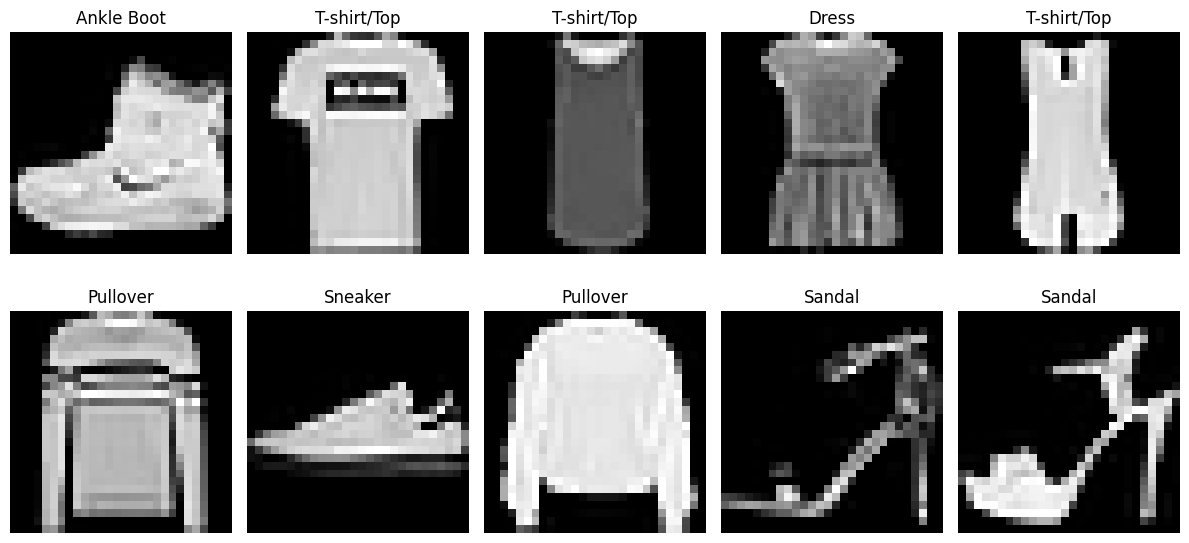

In [ ]:
# ==========================================================
# PLOT 1 : SAMPLE IMAGES
# ==========================================================

import matplotlib.pyplot as plt

class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i].reshape(28,28), cmap='gray')

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.tight_layout()

plt.show()

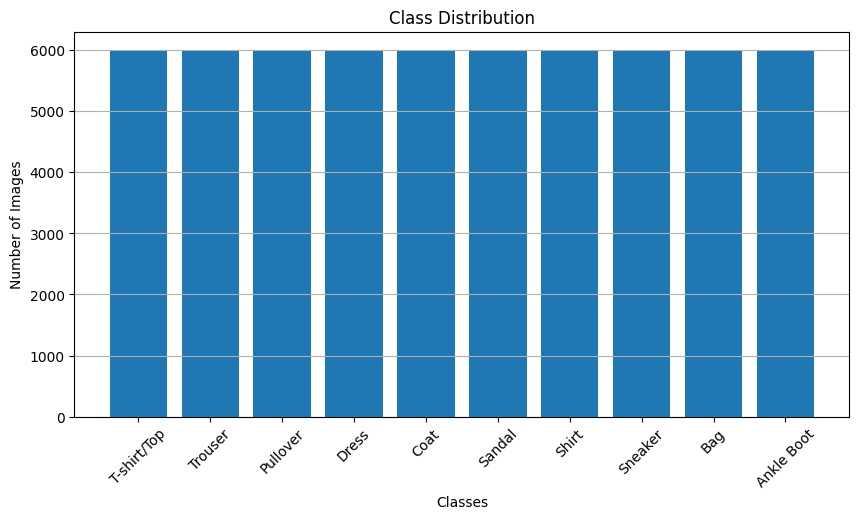

In [ ]:
# ==========================================================
# PLOT 2 : CLASS DISTRIBUTION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Count number of samples in each class
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

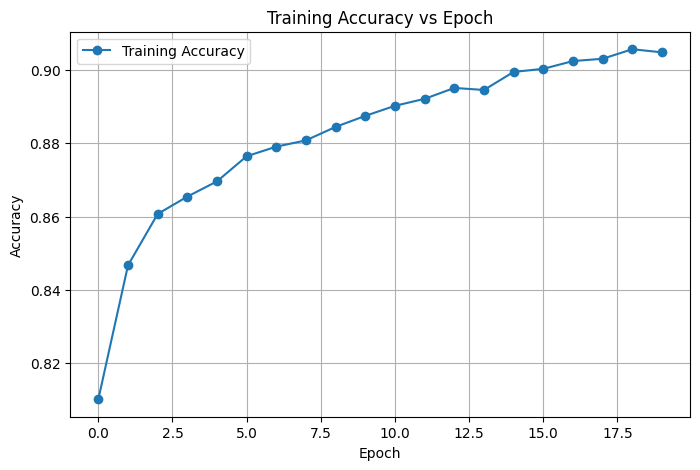

In [ ]:
# ==========================================================
# PLOT 3 : TRAINING ACCURACY VS EPOCH
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(optimized_history.history['accuracy'],
         marker='o',
         label='Training Accuracy')

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

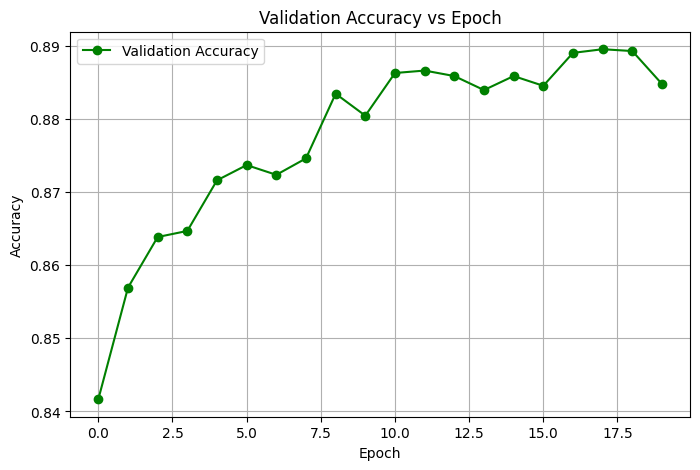

In [ ]:
# ==========================================================
# PLOT 4 : VALIDATION ACCURACY VS EPOCH
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(optimized_history.history['val_accuracy'],
         marker='o',
         color='green',
         label='Validation Accuracy')

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

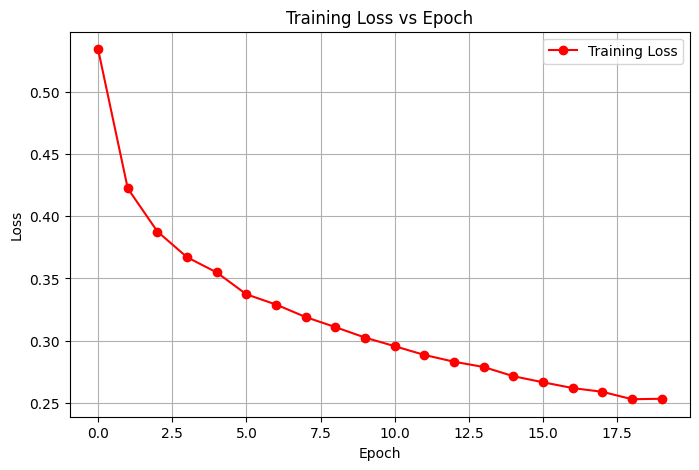

In [ ]:
# ==========================================================
# PLOT 5 : TRAINING LOSS VS EPOCH
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(optimized_history.history['loss'],
         marker='o',
         color='red',
         label='Training Loss')

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

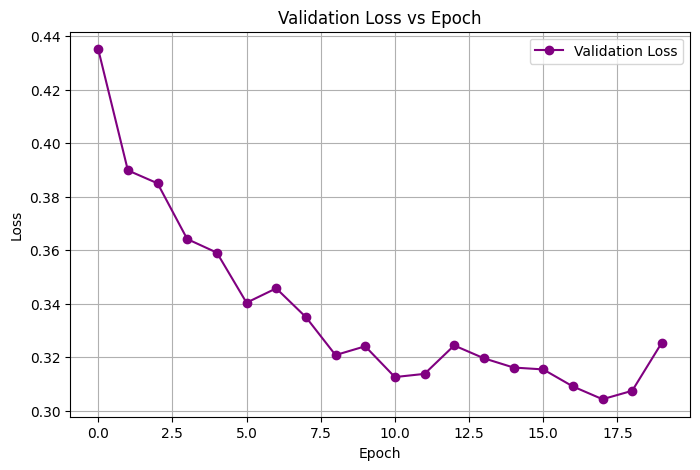

In [ ]:
# ==========================================================
# PLOT 6 : VALIDATION LOSS VS EPOCH
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(optimized_history.history['val_loss'],
         marker='o',
         color='purple',
         label='Validation Loss')

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

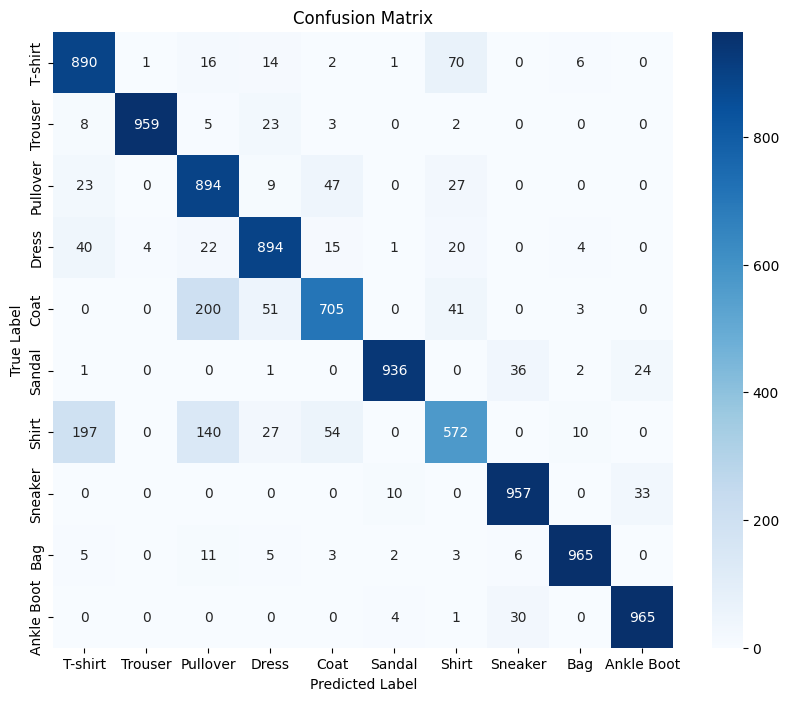

In [ ]:
# ==========================================================
# PLOT 7 : CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

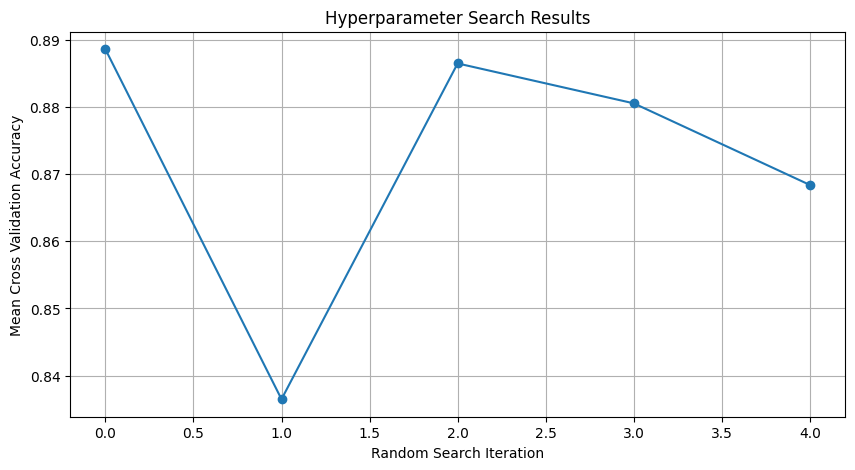

In [ ]:
# ==========================================================
# PLOT 8 : HYPERPARAMETER SEARCH RESULTS
# ==========================================================

results = random_search.cv_results_

plt.figure(figsize=(10,5))

plt.plot(results['mean_test_score'],
         marker='o')

plt.title("Hyperparameter Search Results")

plt.xlabel("Random Search Iteration")

plt.ylabel("Mean Cross Validation Accuracy")

plt.grid(True)

plt.show()

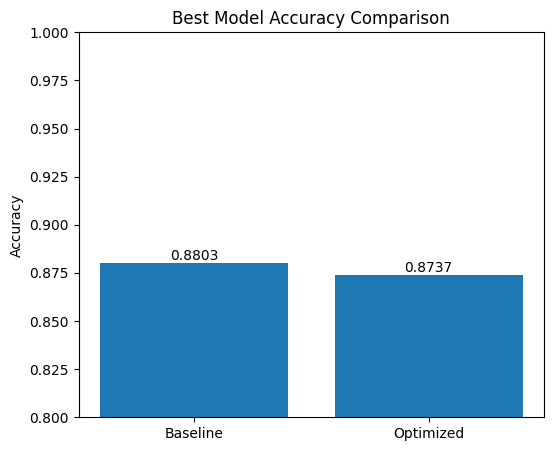

In [ ]:
# ==========================================================
# PLOT 9 : BASELINE VS OPTIMIZED MODEL
# ==========================================================

models = ['Baseline','Optimized']

accuracies = [baseline_accuracy,test_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(models,
               accuracies)

plt.ylabel("Accuracy")

plt.title("Best Model Accuracy Comparison")

for bar in bars:

    height = bar.get_height()

    plt.text(bar.get_x()+bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center',
             va='bottom')

plt.ylim(0.80,1.00)

plt.show()


Epoch: 0

Input -> Hidden Weights
[[ 1.62071936 -0.62464418]
 [-0.52550412 -1.08209038]]

Hidden -> Output Weights
[[ 0.87504103]
 [-2.28994852]]

Hidden Bias
[[ 0.00259776 -0.0224883 ]]

Output Bias
[[0.02848712]]


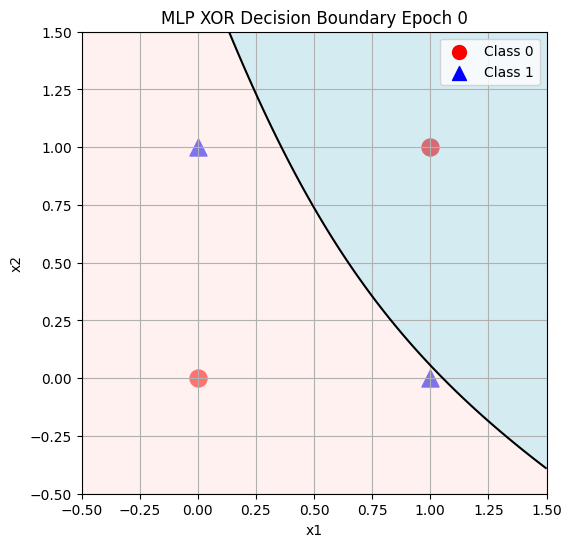


Epoch: 200

Input -> Hidden Weights
[[ 1.02794504 -2.63293066]
 [-0.77807983 -2.77002479]]

Hidden -> Output Weights
[[ 0.23080283]
 [-3.21329176]]

Hidden Bias
[[-0.28775601 -0.06691917]]

Output Bias
[[0.42564689]]


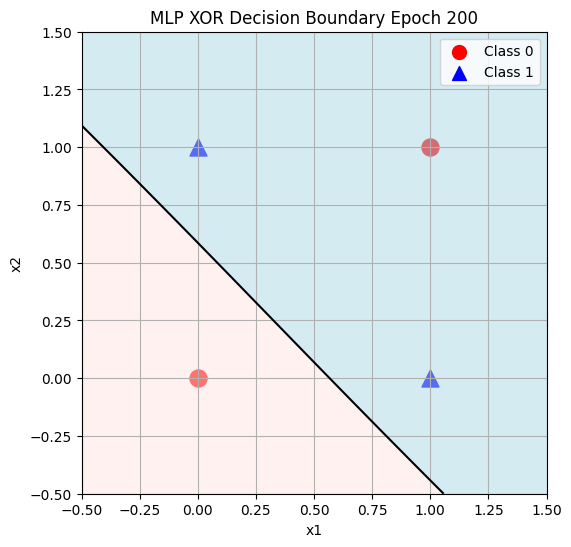


Epoch: 400

Input -> Hidden Weights
[[ 0.59819794 -3.84405388]
 [-1.4039083  -3.97504527]]

Hidden -> Output Weights
[[ 0.68581584]
 [-4.20360064]]

Hidden Bias
[[-0.46604717  0.33073355]]

Output Bias
[[0.46605172]]


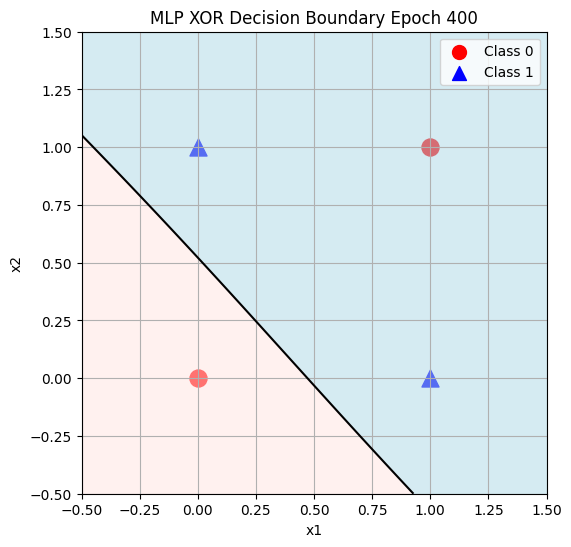


Epoch: 600

Input -> Hidden Weights
[[ 0.33492267 -4.43659892]
 [-2.48512644 -4.78784036]]

Hidden -> Output Weights
[[ 1.99606442]
 [-4.8198353 ]]

Hidden Bias
[[-0.15768998  0.56638408]]

Output Bias
[[0.1719919]]


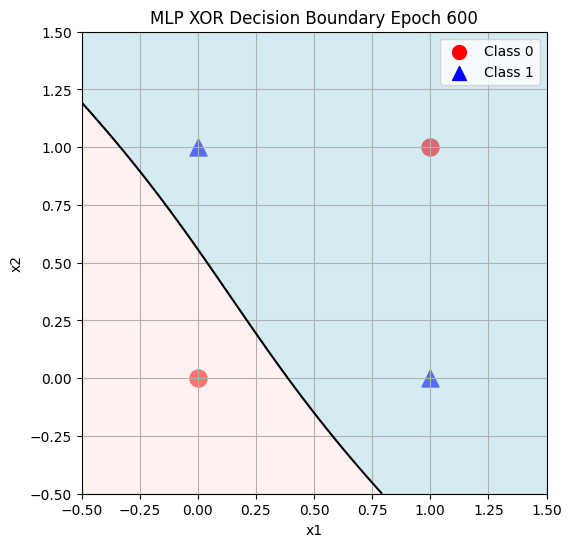


Epoch: 800

Input -> Hidden Weights
[[-2.66986250e-03 -4.74685477e+00]
 [-3.13632084e+00 -5.46946048e+00]]

Hidden -> Output Weights
[[ 2.91148934]
 [-5.39764644]]

Hidden Bias
[[0.3909684  0.87002915]]

Output Bias
[[-0.02855991]]


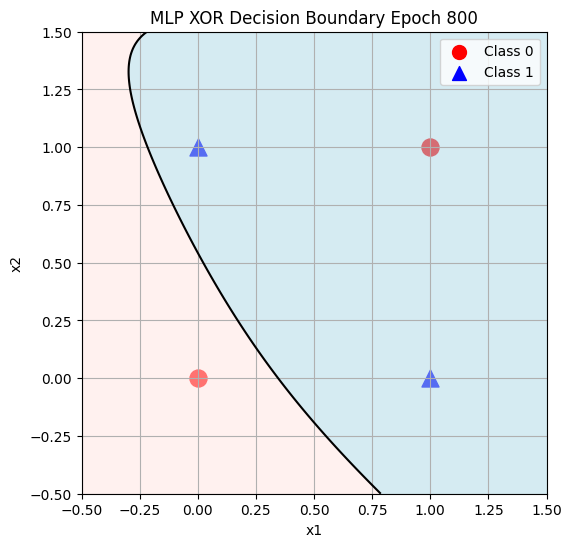


Epoch: 1000

Input -> Hidden Weights
[[-1.52593742 -4.99626134]
 [-2.33470106 -6.01426387]]

Hidden -> Output Weights
[[ 3.86424195]
 [-6.06160482]]

Hidden Bias
[[2.13826905 1.26024734]]

Output Bias
[[-0.86221161]]


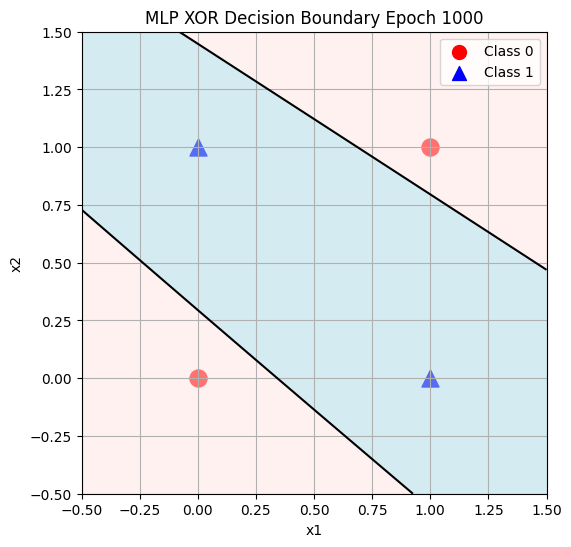


Epoch: 1200

Input -> Hidden Weights
[[-2.78510283 -5.3459684 ]
 [-2.85506115 -6.185056  ]]

Hidden -> Output Weights
[[ 5.64799254]
 [-6.70447225]]

Hidden Bias
[[3.90039511 1.62908394]]

Output Bias
[[-2.24139356]]


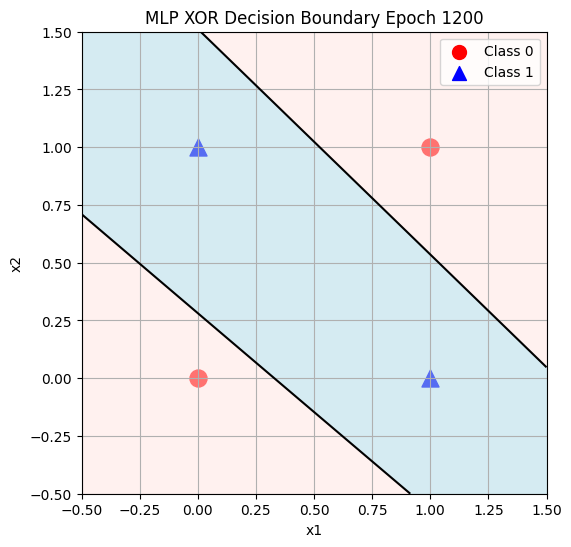


Epoch: 1400

Input -> Hidden Weights
[[-3.20123272 -5.53152761]
 [-3.26764775 -6.26849751]]

Hidden -> Output Weights
[[ 6.4748563 ]
 [-7.16808921]]

Hidden Bias
[[4.61024488 1.87417708]]

Output Bias
[[-2.76518501]]


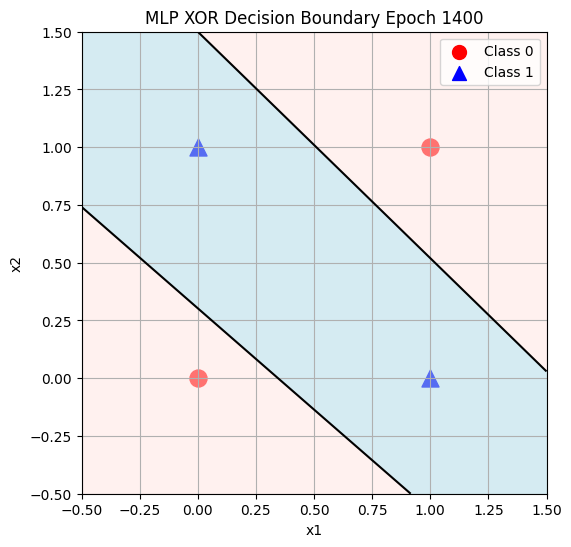


Epoch: 1600

Input -> Hidden Weights
[[-3.43726182 -5.64924362]
 [-3.50458372 -6.32539479]]

Hidden -> Output Weights
[[ 6.9599503 ]
 [-7.49057494]]

Hidden Bias
[[5.00640544 2.01671526]]

Output Bias
[[-3.05913915]]


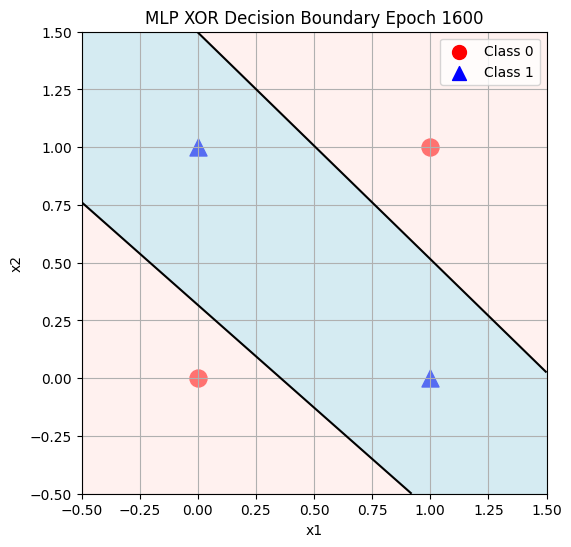


Epoch: 1800

Input -> Hidden Weights
[[-3.59714441 -5.73460676]
 [-3.66499667 -6.36868611]]

Hidden -> Output Weights
[[ 7.29597909]
 [-7.73426239]]

Hidden Bias
[[5.27159145 2.1114539 ]]

Output Bias
[[-3.25776253]]


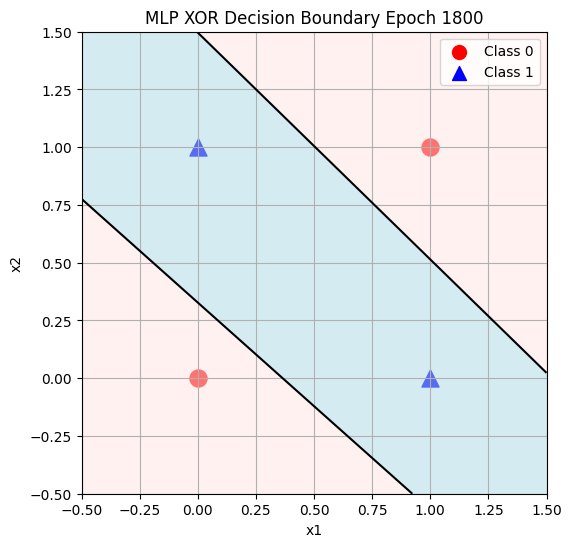


Final Predictions
-----------------
[0 0] => 0  probability: 0.04694903022783927
[0 1] => 1  probability: 0.9451566591908327
[1 0] => 1  probability: 0.9437995345652723
[1 1] => 0  probability: 0.0736817729962572


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =====================================
# XOR Dataset
# =====================================

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])


# =====================================
# Activation Functions
# =====================================

def sigmoid(x):
    return 1/(1+np.exp(-x))


def sigmoid_derivative(x):
    return x*(1-x)



# =====================================
# Initialize Weights
# =====================================

np.random.seed(1)

# Input layer -> Hidden layer
W1 = np.random.randn(2,2)

# Hidden bias
b1 = np.zeros((1,2))


# Hidden layer -> Output layer
W2 = np.random.randn(2,1)

# Output bias
b2 = np.zeros((1,1))


learning_rate = 0.5



# =====================================
# Forward Propagation
# =====================================

def forward(X):

    hidden_input = np.dot(X,W1) + b1

    hidden_output = sigmoid(hidden_input)


    output_input = np.dot(hidden_output,W2) + b2

    output = sigmoid(output_input)


    return output, hidden_output



# =====================================
# Plot Decision Boundary
# =====================================

def plot_boundary(epoch):

    plt.figure(figsize=(6,6))


    # ----------------------------
    # Plot actual XOR classes
    # ----------------------------

    for i in range(len(X)):

        if y[i] == 1:

            plt.scatter(
                X[i][0],
                X[i][1],
                color="blue",
                marker="^",
                s=150
            )

        else:

            plt.scatter(
                X[i][0],
                X[i][1],
                color="red",
                marker="o",
                s=150
            )


    # ----------------------------
    # Create decision map
    # ----------------------------

    xx,yy = np.meshgrid(
        np.linspace(-0.5,1.5,200),
        np.linspace(-0.5,1.5,200)
    )


    grid = np.c_[xx.ravel(),yy.ravel()]


    predictions=[]


    for point in grid:

        result,_ = forward(point.reshape(1,2))

        predictions.append(result[0][0])


    predictions=np.array(predictions)

    predictions=predictions.reshape(xx.shape)



    # Background decision regions

    plt.contourf(
        xx,
        yy,
        predictions,
        levels=[0,0.5,1],
        colors=["mistyrose","lightblue"],
        alpha=0.5
    )


    # Decision boundary line

    plt.contour(
        xx,
        yy,
        predictions,
        levels=[0.5],
        colors="black"
    )


    # Labels

    plt.scatter([],[],
                color="red",
                marker="o",
                s=100,
                label="Class 0")

    plt.scatter([],[],
                color="blue",
                marker="^",
                s=100,
                label="Class 1")


    plt.legend()

    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.title(
        "MLP XOR Decision Boundary Epoch "+str(epoch)
    )

    plt.grid()

    plt.show()



# =====================================
# Train MLP
# =====================================

epochs = 2000


for epoch in range(epochs):


    # Forward pass

    output, hidden_output = forward(X)



    # Error

    error = y-output



    # -----------------------------
    # Backpropagation
    # -----------------------------


    output_delta = (
        error *
        sigmoid_derivative(output)
    )


    hidden_error = output_delta.dot(W2.T)


    hidden_delta = (
        hidden_error *
        sigmoid_derivative(hidden_output)
    )



    # -----------------------------
    # Weight Updates
    # -----------------------------


    W2 += hidden_output.T.dot(output_delta) * learning_rate

    b2 += np.sum(
        output_delta,
        axis=0,
        keepdims=True
    ) * learning_rate



    W1 += X.T.dot(hidden_delta) * learning_rate

    b1 += np.sum(
        hidden_delta,
        axis=0,
        keepdims=True
    ) * learning_rate



    # Show updates every 200 epochs

    if epoch % 200 == 0:


        print("\n========================")
        print("Epoch:",epoch)
        print("========================")


        print("\nInput -> Hidden Weights")
        print(W1)


        print("\nHidden -> Output Weights")
        print(W2)


        print("\nHidden Bias")
        print(b1)


        print("\nOutput Bias")
        print(b2)



        plot_boundary(epoch)



# =====================================
# Final Testing
# =====================================

print("\nFinal Predictions")
print("-----------------")


for i in range(len(X)):

    prediction,_ = forward(
        X[i].reshape(1,2)
    )


    print(
        X[i],
        "=>",
        round(prediction[0][0]),
        " probability:",
        prediction[0][0]
    )